In [18]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Subset
import random
from collections import defaultdict
from collections import Counter
from sklearn.decomposition import PCA

Import all necessary libraries

In [19]:
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

In [20]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

rotate = transforms.Compose([
    transforms.RandomRotation(degrees=30),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

flip = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

crop = transforms.Compose([
    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0),
        ratio=(0.9, 1.1)
    ),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

erase = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing()
])

affine = transforms.Compose([
    transforms.RandomAffine(
        degrees=10,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
        shear=5
    ),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

blur = transforms.Compose([
    transforms.GaussianBlur(3, sigma=(0.1, 0.5)),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [21]:
CAT_LABEL = 3
DOG_LABEL = 5

# Load dataset
total_trainset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True, download=True, 
    transform=transform
)
rotate_trainset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True, download=True, 
    transform=rotate
)
flip_trainset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True, download=True, 
    transform=flip
)
crop_trainset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True, download=True, 
    transform=crop
)
erase_trainset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True, download=True, 
    transform=erase
)
affine_trainset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True, download=True, 
    transform=affine
)
blur_trainset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True, download=True, 
    transform=blur
)

In [22]:
def balanced_cat_dog_indices(dataset, total_samples):
    class_indices = defaultdict(list)

    for i, (_, label) in enumerate(dataset):
        if label in [CAT_LABEL, DOG_LABEL]:
            class_indices[label].append(i)

    samples_per_class = total_samples // 2

    cat_indices = random.sample(class_indices[CAT_LABEL], samples_per_class)
    dog_indices = random.sample(class_indices[DOG_LABEL], samples_per_class)

    indices = cat_indices + dog_indices
    random.shuffle(indices)
    return indices

indices_500 = balanced_cat_dog_indices(total_trainset, 500)
indices_5000 = balanced_cat_dog_indices(total_trainset, 5000)
indices_500_aug = indices_500


trainset_500 = Subset(total_trainset, indices_500)
trainset_5000 = Subset(total_trainset, indices_5000)
trainset_500_rotate = Subset(rotate_trainset, indices_500_aug)
trainset_500_flip = Subset(flip_trainset, indices_500_aug)
trainset_500_crop = Subset(crop_trainset, indices_500_aug)
trainset_500_erase = Subset(erase_trainset, indices_500_aug)
trainset_500_affine = Subset(affine_trainset, indices_500_aug)
trainset_500_blur = Subset(blur_trainset, indices_500_aug)

class CatDogDataset(torch.utils.data.Dataset):
    def __init__(self, subset):
        self.subset = subset

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        label = 0 if label == CAT_LABEL else 1
        return image, label

trainset_500 = CatDogDataset(trainset_500)
trainset_5000 = CatDogDataset(trainset_5000)
trainset_500_rotate = CatDogDataset(trainset_500_rotate)
trainset_500_flip = CatDogDataset(trainset_500_flip)
trainset_500_crop = CatDogDataset(trainset_500_crop)
trainset_500_erase = CatDogDataset(trainset_500_erase)
trainset_500_affine = CatDogDataset(trainset_500_affine)
trainset_500_blur = CatDogDataset(trainset_500_blur)


trainloader_500 = torch.utils.data.DataLoader(
    trainset_500,
    batch_size=40,
    shuffle=True
)

trainloader_5000 = torch.utils.data.DataLoader(
    trainset_5000,
    batch_size=160,
    shuffle=True
)

trainloader_500_rotate = torch.utils.data.DataLoader(
    trainset_500_rotate,
    batch_size=40,
    shuffle=True
)

trainloader_500_flip = torch.utils.data.DataLoader(
    trainset_500_flip,
    batch_size=40,
    shuffle=True
)

trainloader_500_crop = torch.utils.data.DataLoader(
    trainset_500_crop,
    batch_size=40,
    shuffle=True
)

trainloader_500_erase = torch.utils.data.DataLoader(
    trainset_500_erase,
    batch_size=40,
    shuffle=True
)

trainloader_500_affine = torch.utils.data.DataLoader(
    trainset_500_affine,
    batch_size=40,
    shuffle=True
)

trainloader_500_blur = torch.utils.data.DataLoader(
    trainset_500_blur,
    batch_size=40,
    shuffle=True
)

full_testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

test_indices = [
    i for i, (_, label) in enumerate(full_testset)
    if label in [CAT_LABEL, DOG_LABEL]
]

testset = CatDogDataset(Subset(full_testset, test_indices))

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)


labels_500 = [label for _, label in trainset_500]
labels_5000 = [label for _, label in trainset_5000]
labels_500_rotate = [label for _, label in trainset_500_rotate]
labels_500_flip = [label for _, label in trainset_500_flip]
labels_500_crop = [label for _, label in trainset_500_crop]
labels_500_erase = [label for _, label in trainset_500_erase]
labels_500_affine = [label for _, label in trainset_500_affine]
labels_500_blur = [label for _, label in trainset_500_blur]

print("500-sample distribution:", Counter(labels_500))
print("5000-sample distribution:", Counter(labels_5000))
print("rotated 500-sample distribution:", Counter(labels_500_rotate))
print("flipped 500-sample distribution:", Counter(labels_500_flip))
print("cropped 500-sample distribution:", Counter(labels_500_crop))
print("erased 500-sample distribution:", Counter(labels_500_erase))
print("affined 500-sample distribution:", Counter(labels_500_affine))
print("blurred 500-sample distribution:", Counter(labels_500_blur))

500-sample distribution: Counter({0: 250, 1: 250})
5000-sample distribution: Counter({1: 2500, 0: 2500})
rotated 500-sample distribution: Counter({0: 250, 1: 250})
flipped 500-sample distribution: Counter({0: 250, 1: 250})
cropped 500-sample distribution: Counter({0: 250, 1: 250})
erased 500-sample distribution: Counter({0: 250, 1: 250})
affined 500-sample distribution: Counter({0: 250, 1: 250})
blurred 500-sample distribution: Counter({0: 250, 1: 250})


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Load the pretrained model for each one
model500 = models.resnet18(pretrained=True)
model5000 = models.resnet18(pretrained=True)
model500_rotate = models.resnet18(pretrained=True)
model500_flip = models.resnet18(pretrained=True)
model500_crop = models.resnet18(pretrained=True)
model500_erase = models.resnet18(pretrained=True)
model500_affine = models.resnet18(pretrained=True)
model500_blur = models.resnet18(pretrained=True)

model500.fc = nn.Linear(model500.fc.in_features, 2)
model5000.fc = nn.Linear(model5000.fc.in_features, 2)
model500_rotate.fc = nn.Linear(model500_rotate.fc.in_features, 2)
model500_flip.fc = nn.Linear(model500_flip.fc.in_features, 2)
model500_crop.fc = nn.Linear(model500_crop.fc.in_features, 2)
model500_erase.fc = nn.Linear(model500_erase.fc.in_features, 2)
model500_affine.fc = nn.Linear(model500_affine.fc.in_features, 2)
model500_blur.fc = nn.Linear(model500_blur.fc.in_features, 2)


model500 = model500.to(device)
model5000 = model5000.to(device)
model500_rotate = model500_rotate.to(device)
model500_flip = model500_flip.to(device)
model500_crop = model500_crop.to(device)
model500_erase = model500_erase.to(device)
model500_affine = model500_affine.to(device)
model500_blur = model500_blur.to(device)


for name, param in model500.named_parameters():
    if ('layer3' in name) or ('layer4' in name) or ('fc' in name):
        param.requires_grad = True
    else:
        param.requires_grad = False

for name, param in model5000.named_parameters():
    if ('layer3' in name) or ('layer4' in name) or ('fc' in name):
        param.requires_grad = True
    else:
        param.requires_grad = False
        
for name, param in model500_rotate.named_parameters():
    if ('layer3' in name) or ('layer4' in name) or ('fc' in name):
        param.requires_grad = True
    else:
        param.requires_grad = False

for name, param in model500_flip.named_parameters():
    if ('layer3' in name) or ('layer4' in name) or ('fc' in name):
        param.requires_grad = True
    else:
        param.requires_grad = False
        
for name, param in model500_crop.named_parameters():
    if ('layer3' in name) or ('layer4' in name) or ('fc' in name):
        param.requires_grad = True
    else:
        param.requires_grad = False

for name, param in model500_erase.named_parameters():
    if ('layer3' in name) or ('layer4' in name) or ('fc' in name):
        param.requires_grad = True
    else:
        param.requires_grad = False

for name, param in model500_affine.named_parameters():
    if ('layer3' in name) or ('layer4' in name) or ('fc' in name):
        param.requires_grad = True
    else:
        param.requires_grad = False

for name, param in model500_blur.named_parameters():
    if ('layer3' in name) or ('layer4' in name) or ('fc' in name):
        param.requires_grad = True
    else:
        param.requires_grad = False




#define loss function and optimizer
loss_function = nn.CrossEntropyLoss()

optimizer500 = optim.Adam(
    filter(lambda p: p.requires_grad, model500.parameters()),
    lr=1e-4
)

optimizer5000 = optim.Adam(
    filter(lambda p: p.requires_grad, model5000.parameters()),
    lr=1e-4
)
optimizer500_rotate = optim.Adam(
    filter(lambda p: p.requires_grad, model500_rotate.parameters()),
    lr=1e-4
)
optimizer500_flip = optim.Adam(
    filter(lambda p: p.requires_grad, model500_flip.parameters()),
    lr=1e-4
)
optimizer500_crop = optim.Adam(
    filter(lambda p: p.requires_grad, model500_crop.parameters()),
    lr=1e-4
)
optimizer500_erase = optim.Adam(
    filter(lambda p: p.requires_grad, model500_erase.parameters()),
    lr=1e-4
)
optimizer500_affine = optim.Adam(
    filter(lambda p: p.requires_grad, model500_affine.parameters()),
    lr=1e-4
)
optimizer500_blur = optim.Adam(
    filter(lambda p: p.requires_grad, model500_blur.parameters()),
    lr=1e-4
)


print('ready for training!')

D:\Arjun\Anaconda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\Arjun\Anaconda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ready for training!


Train the final layers of each!

In [24]:
def train_loop(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)
    model.train()

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

        if batch % 10 == 0:
            loss_val = loss.item()
            current = batch * len(X)
            print(f"loss: {loss_val:.4f}  [{current}/{size}]")

            
def test_loop(dataloader, model, loss_fn, device):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    test_loss, correct = 0.0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(dim=1) == y).sum().item()

    test_loss /= num_batches
    accuracy = correct / size

    print(f"Test Error:\n Accuracy: {accuracy*100:.2f}%, Avg loss: {test_loss:.4f}\n")

num_epochs = 10

print("Training model with 500 samples")
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}")
    train_loop(trainloader_500, model500, loss_function, optimizer500, device)
    test_loop(testloader, model500, loss_function, device)

print("Training model with 5000 samples")
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}")
    train_loop(trainloader_5000, model5000, loss_function, optimizer5000, device)
    test_loop(testloader, model5000, loss_function, device)

print("Training model with 500 rotated samples")
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}")
    train_loop(trainloader_500_rotate, model500_rotate, loss_function, optimizer500_rotate, device)
    test_loop(testloader, model500_rotate, loss_function, device)

print("Training model with 500 flipped samples")
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}")
    train_loop(trainloader_500_flip, model500_flip, loss_function, optimizer500_flip, device)
    test_loop(testloader, model500_flip, loss_function, device)

print("Training model with 500 cropped samples")
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}")
    train_loop(trainloader_500_crop, model500_crop, loss_function, optimizer500_crop, device)
    test_loop(testloader, model500_crop, loss_function, device)

print("Training model with 500 erased samples")
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}")
    train_loop(trainloader_500_erase, model500_erase, loss_function, optimizer500_erase, device)
    test_loop(testloader, model500_erase, loss_function, device)

print("Training model with 500 affined samples")
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}")
    train_loop(trainloader_500_affine, model500_affine, loss_function, optimizer500_affine, device)
    test_loop(testloader, model500_affine, loss_function, device)

print("Training model with 500 blurred samples")
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}")
    train_loop(trainloader_500_blur, model500_blur, loss_function, optimizer500_blur, device)
    test_loop(testloader, model500_blur, loss_function, device)

Training model with 500 samples
Epoch 1
loss: 0.7288  [0/500]
loss: 0.4551  [400/500]
Test Error:
 Accuracy: 78.05%, Avg loss: 0.4690

Epoch 2
loss: 0.1353  [0/500]
loss: 0.0959  [400/500]
Test Error:
 Accuracy: 83.95%, Avg loss: 0.3906

Epoch 3
loss: 0.0203  [0/500]
loss: 0.0286  [400/500]
Test Error:
 Accuracy: 84.70%, Avg loss: 0.3947

Epoch 4
loss: 0.0150  [0/500]
loss: 0.0040  [400/500]
Test Error:
 Accuracy: 84.25%, Avg loss: 0.4243

Epoch 5
loss: 0.0033  [0/500]
loss: 0.0025  [400/500]
Test Error:
 Accuracy: 84.00%, Avg loss: 0.4460

Epoch 6
loss: 0.0032  [0/500]
loss: 0.0028  [400/500]
Test Error:
 Accuracy: 83.20%, Avg loss: 0.4660

Epoch 7
loss: 0.0018  [0/500]
loss: 0.0036  [400/500]
Test Error:
 Accuracy: 83.55%, Avg loss: 0.4741

Epoch 8
loss: 0.0028  [0/500]
loss: 0.0030  [400/500]
Test Error:
 Accuracy: 83.55%, Avg loss: 0.4778

Epoch 9
loss: 0.0225  [0/500]
loss: 0.0013  [400/500]
Test Error:
 Accuracy: 83.35%, Avg loss: 0.4808

Epoch 10
loss: 0.0009  [0/500]
loss: 0.00

In [25]:
activations500 = []
activations5000 = []
activations500_rotate = []
activations500_flip = []
activations500_crop = []
activations500_erase = []
activations500_affine = []
activations500_blur = []

act500_labels = []
act5000_labels = []
act500_labels_rotate = []
act500_labels_flip = []
act500_labels_crop = []
act500_labels_erase = []
act500_labels_affine = []
act500_labels_blur = []

def hook500_fn(module, input, output):
    activations500.append(output.detach().cpu())

def hook5000_fn(module, input, output):
    activations5000.append(output.detach().cpu())

def hook500_fn_rotate(module, input, output):
    activations500_rotate.append(output.detach().cpu())

def hook500_fn_flip(module, input, output):
    activations500_flip.append(output.detach().cpu())

def hook500_fn_crop(module, input, output):
    activations500_crop.append(output.detach().cpu())

def hook500_fn_erase(module, input, output):
    activations500_erase.append(output.detach().cpu())

def hook500_fn_affine(module, input, output):
    activations500_affine.append(output.detach().cpu())

def hook500_fn_blur(module, input, output):
    activations500_blur.append(output.detach().cpu())


hook500 = model500.avgpool.register_forward_hook(hook500_fn)
hook5000 = model5000.avgpool.register_forward_hook(hook5000_fn)
hook500_rotate = model500_rotate.avgpool.register_forward_hook(hook500_fn_rotate)
hook500_flip = model500_flip.avgpool.register_forward_hook(hook500_fn_flip)
hook500_crop = model500_crop.avgpool.register_forward_hook(hook500_fn_crop)
hook500_erase = model500_erase.avgpool.register_forward_hook(hook500_fn_erase)
hook500_affine = model500_affine.avgpool.register_forward_hook(hook500_fn_affine)
hook500_blur = model500_blur.avgpool.register_forward_hook(hook500_fn_blur)


model500.eval()
model5000.eval()
model500_rotate.eval()
model500_flip.eval()
model500_crop.eval()
model500_erase.eval()
model500_affine.eval()
model500_blur.eval()


with torch.no_grad():
    for X, y in testloader:
        X = X.to(device)
        _ = model500(X) # forward pass triggers hook
        act500_labels.extend(y.numpy())

with torch.no_grad():
    for X, y in testloader:
        X = X.to(device)
        _ = model5000(X)          
        act5000_labels.extend(y.numpy())

with torch.no_grad():
    for X, y in testloader:
        X = X.to(device)
        _ = model500_rotate(X)         
        act500_labels_rotate.extend(y.numpy())
        
with torch.no_grad():
    for X, y in testloader:
        X = X.to(device)
        _ = model500_flip(X)         
        act500_labels_flip.extend(y.numpy())

with torch.no_grad():
    for X, y in testloader:
        X = X.to(device)
        _ = model500_crop(X)         
        act500_labels_crop.extend(y.numpy())

with torch.no_grad():
    for X, y in testloader:
        X = X.to(device)
        _ = model500_erase(X)         
        act500_labels_erase.extend(y.numpy())

with torch.no_grad():
    for X, y in testloader:
        X = X.to(device)
        _ = model500_affine(X)         
        act500_labels_affine.extend(y.numpy())

with torch.no_grad():
    for X, y in testloader:
        X = X.to(device)
        _ = model500_blur(X)         
        act500_labels_blur.extend(y.numpy())

hook500.remove()
hook5000.remove()
hook500_rotate.remove()
hook500_flip.remove()
hook500_crop.remove()
hook500_erase.remove()
hook500_affine.remove()
hook500_blur.remove()

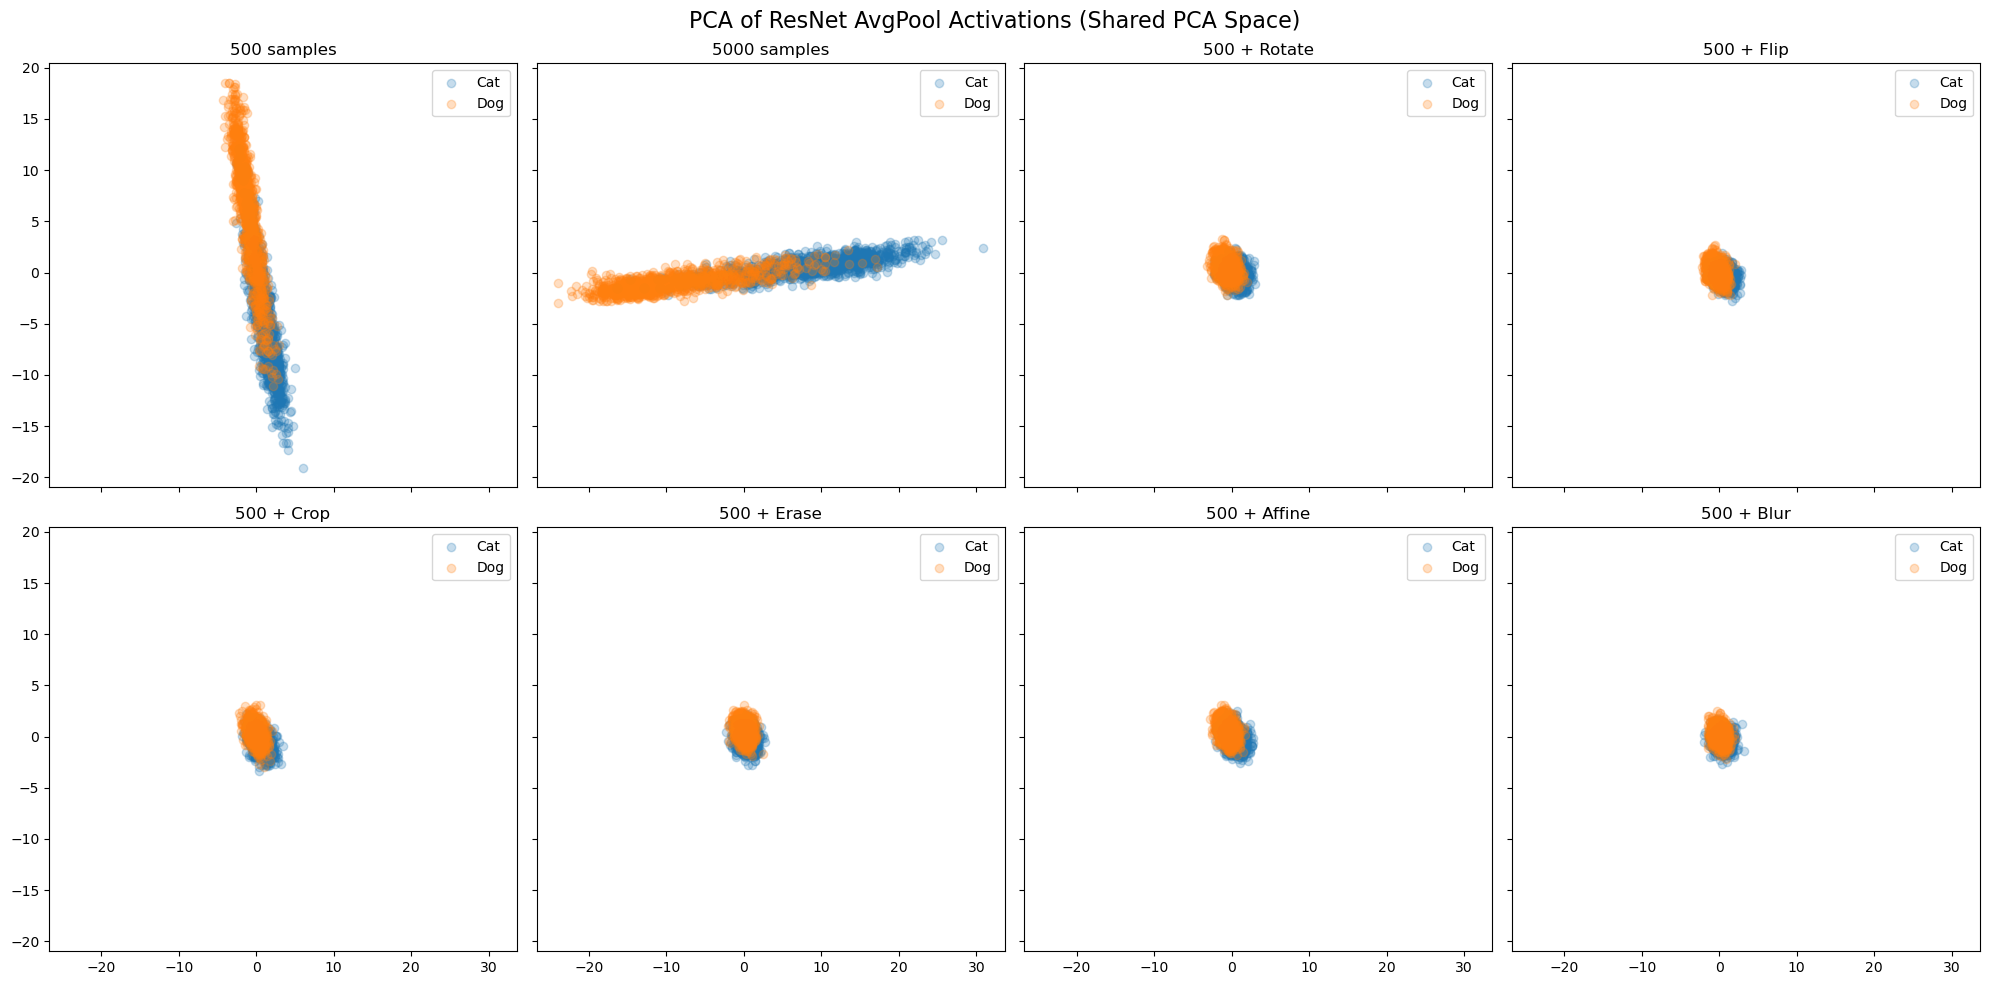

In [26]:
def flatten_acts(acts):
    acts = torch.cat(acts, dim=0)
    return acts.view(acts.size(0), -1)

acts500 = flatten_acts(activations500)
acts5000 = flatten_acts(activations5000)

acts500_rotate = flatten_acts(activations500_rotate)
acts500_flip   = flatten_acts(activations500_flip)
acts500_crop   = flatten_acts(activations500_crop)
acts500_erase  = flatten_acts(activations500_erase)
acts500_affine = flatten_acts(activations500_affine)
acts500_blur   = flatten_acts(activations500_blur)

acts_all = torch.cat([acts500, acts5000], dim=0)

pca = PCA(n_components=2)
acts_all_2d = pca.fit_transform(acts_all.numpy())

n500 = acts500.shape[0]
acts500_2d  = acts_all_2d[:n500]
acts5000_2d = acts_all_2d[n500:]
acts500_rotate_2d = pca.transform(acts500_rotate.numpy())
acts500_flip_2d   = pca.transform(acts500_flip.numpy())
acts500_crop_2d   = pca.transform(acts500_crop.numpy())
acts500_erase_2d  = pca.transform(acts500_erase.numpy())
acts500_affine_2d = pca.transform(acts500_affine.numpy())
acts500_blur_2d   = pca.transform(acts500_blur.numpy())

labels500        = np.array(act500_labels)
labels5000       = np.array(act5000_labels)
labels500_rotate = np.array(act500_labels_rotate)
labels500_flip   = np.array(act500_labels_flip)
labels500_crop   = np.array(act500_labels_crop)
labels500_erase  = np.array(act500_labels_erase)
labels500_affine = np.array(act500_labels_affine)
labels500_blur   = np.array(act500_labels_blur)

fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)

def plot_panel(ax, data, labels, title):
    ax.scatter(data[labels == 0, 0], data[labels == 0, 1],
               label="Cat", alpha=0.25)
    ax.scatter(data[labels == 1, 0], data[labels == 1, 1],
               label="Dog", alpha=0.25)
    ax.set_title(title)
    ax.legend()

plot_panel(axes[0, 0], acts500_2d, labels500,"500 samples")
plot_panel(axes[0, 1], acts5000_2d,labels5000,"5000 samples")
plot_panel(axes[0, 2], acts500_rotate_2d,labels500_rotate,"500 + Rotate")
plot_panel(axes[0, 3], acts500_flip_2d,labels500_flip,"500 + Flip")
plot_panel(axes[1, 0], acts500_crop_2d,labels500_crop,"500 + Crop")
plot_panel(axes[1, 1], acts500_erase_2d,labels500_erase,"500 + Erase")
plot_panel(axes[1, 2], acts500_affine_2d,labels500_affine,"500 + Affine")
plot_panel(axes[1, 3], acts500_blur_2d,labels500_blur,"500 + Blur")

plt.suptitle(
    "PCA of ResNet AvgPool Activations (Shared PCA Space)",
    fontsize=16
)
plt.tight_layout()
plt.show()

In [27]:
from sklearn.metrics import silhouette_score

print("Silhouette 500:", silhouette_score(acts500, labels500))
print("Silhouette 5000:", silhouette_score(acts5000, labels5000))
print("Silhouette 500 + Rotate:", silhouette_score(acts500_rotate, labels500_rotate))
print("Silhouette 500 + Flip:", silhouette_score(acts500_flip, labels500_flip))
print("Silhouette 500 + Crop:", silhouette_score(acts500_crop, labels500_crop))
print("Silhouette 500 + Erase:", silhouette_score(acts500_erase, labels500_erase))
print("Silhouette 500 + Affine:", silhouette_score(acts500_affine, labels500_affine))
print("Silhouette 500 + Blur:", silhouette_score(acts500_blur, labels500_blur))

Silhouette 500: 0.11108149588108063
Silhouette 5000: 0.23798170685768127
Silhouette 500 + Rotate: 0.10315152257680893
Silhouette 500 + Flip: 0.12486829608678818
Silhouette 500 + Crop: 0.12492531538009644
Silhouette 500 + Erase: 0.1098770871758461
Silhouette 500 + Affine: 0.11770687997341156
Silhouette 500 + Blur: 0.1204388216137886
